# Person 2 Prototype: IoU Trigger + State Memory

Goal: validate IoU spike detection and 3-state memory using synthetic boxes.
- Inputs are synthetic agent/object boxes per frame.
- Trigger uses rolling baseline + spike threshold with cooldown.
- State memory tracks unknown/closed/open transitions.

## Person 1 Interfaces (Expected)

These functions are required from the ingest + detection stack and are referenced by the interaction stage:

- `load_video_frames(video_path)` -> yields `(frame_idx, timestamp_sec, frame_image)`
- `detect_objects(frame_image)` -> returns list of `Detection` (class_id, score, box)
- `track_objects(detections)` -> returns list of `Track` (track_id, class_id, score, box)

The interaction stage uses the tracked `box` outputs to compute IoU and triggers.

In [ ]:
from dataclasses import dataclass
from typing import Iterable, List, Tuple

@dataclass(frozen=True)
class Detection:
    class_id: str
    score: float
    box: Box


@dataclass(frozen=True)
class Track:
    track_id: str
    class_id: str
    score: float
    box: Box


def load_video_frames(video_path: str) -> Iterable[Tuple[int, float, object]]:
    raise NotImplementedError("Provided by Person 1: ingest/video_loader.py")


def detect_objects(frame_image: object) -> List[Detection]:
    raise NotImplementedError("Provided by Person 1: detection/yolo_detector.py")


def track_objects(detections: List[Detection]) -> List[Track]:
    raise NotImplementedError("Provided by Person 1: detection/bytetrack_tracker.py")

In [ ]:
USE_PERSON1_PIPELINE = False

if USE_PERSON1_PIPELINE:
    for frame_idx, timestamp_sec, frame_img in load_video_frames("sample.mp4"):
        detections = detect_objects(frame_img)
        tracks = track_objects(detections)
        # Convert tracks to (agent_boxes, object_boxes) for IoU triggering.
        # This is intentionally a placeholder until Person 1 modules exist.

In [2]:
from collections import deque
from dataclasses import dataclass
from typing import Dict, List, Tuple

Box = Tuple[float, float, float, float]  # x1, y1, x2, y2

def iou(box_a: Box, box_b: Box) -> float:
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union_area = area_a + area_b - inter_area
    return inter_area / union_area if union_area > 0 else 0.0

In [3]:
def make_box(cx: float, cy: float, w: float, h: float) -> Box:
    return (cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2)

frames = list(range(60))
door_box = make_box(5.0, 5.0, 2.0, 4.0)
agent_boxes: List[Box] = []

# Agent moves toward the door, overlaps, then passes through.
for t in frames:
    cx = 0.5 + (t / 59) * 7.0
    cy = 5.0
    agent_boxes.append(make_box(cx, cy, 2.0, 2.0))

ious = [iou(b, door_box) for b in agent_boxes]
ious[:5], ious[-5:]

([0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0])

In [4]:
@dataclass
class TriggerEvent:
    frame_idx: int
    iou_value: float
    baseline: float
    window_start: int
    window_end: int


class RollingSpikeTrigger:
    def __init__(
        self,
        baseline_window: int = 8,
        spike_delta: float = 0.15,
        min_iou: float = 0.05,
        cooldown_frames: int = 6,
        event_window: int = 10,
    ) -> None:
        self.baseline_window = baseline_window
        self.spike_delta = spike_delta
        self.min_iou = min_iou
        self.cooldown_frames = cooldown_frames
        self.event_window = event_window
        self._history: deque = deque(maxlen=baseline_window)
        self._last_trigger_frame = -10**9

    def step(self, frame_idx: int, iou_value: float) -> Tuple[bool, float, float, bool]:
        baseline = sum(self._history) / len(self._history) if self._history else 0.0
        can_trigger = (frame_idx - self._last_trigger_frame) >= self.cooldown_frames
        spike = (iou_value - baseline) >= self.spike_delta and iou_value >= self.min_iou
        triggered = bool(can_trigger and spike)
        if triggered:
            self._last_trigger_frame = frame_idx
        self._history.append(iou_value)
        in_window = frame_idx < (self._last_trigger_frame + self.event_window)
        return triggered, baseline, iou_value - baseline, in_window

    def event_from_step(self, frame_idx: int, iou_value: float) -> Tuple[bool, TriggerEvent]:
        triggered, baseline, _delta, _in_window = self.step(frame_idx, iou_value)
        if not triggered:
            return False, None
        return True, TriggerEvent(
            frame_idx=frame_idx,
            iou_value=iou_value,
            baseline=baseline,
            window_start=frame_idx,
            window_end=frame_idx + self.event_window,
        )

trigger = RollingSpikeTrigger()
events: List[TriggerEvent] = []
baseline_series: List[float] = []
delta_series: List[float] = []
in_window_series: List[bool] = []

for frame_idx, value in enumerate(ious):
    triggered, baseline, delta, in_window = trigger.step(frame_idx, value)
    baseline_series.append(baseline)
    delta_series.append(delta)
    in_window_series.append(in_window)
    if triggered:
        events.append(TriggerEvent(
            frame_idx=frame_idx,
            iou_value=value,
            baseline=baseline,
            window_start=frame_idx,
            window_end=frame_idx + trigger.event_window,
        ))

events

[TriggerEvent(frame_idx=36, iou_value=0.41883767535070143, baseline=0.26391450058202587, window_start=36, window_end=46)]

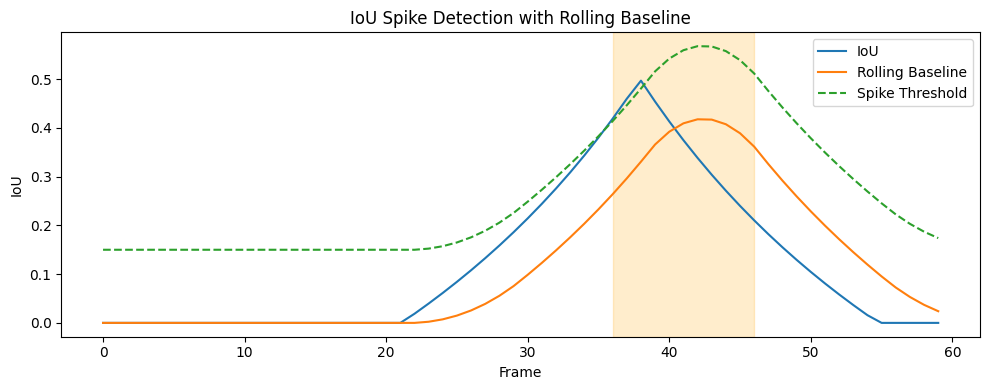

In [5]:
try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))
    plt.plot(frames, ious, label="IoU")
    plt.plot(frames, baseline_series, label="Rolling Baseline")
    plt.plot(frames, [b + 0.15 for b in baseline_series], label="Spike Threshold", linestyle="--")
    for ev in events:
        plt.axvspan(ev.window_start, ev.window_end, color="orange", alpha=0.2)
    plt.title("IoU Spike Detection with Rolling Baseline")
    plt.xlabel("Frame")
    plt.ylabel("IoU")
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("Plot skipped:", exc)

In [6]:
@dataclass
class StateTransition:
    object_id: str
    frame_idx: int
    before: str
    after: str
    reason: str


class StateMemory:
    def __init__(self) -> None:
        self._states: Dict[str, str] = {}
        self._history: List[StateTransition] = []

    def get_state(self, object_id: str) -> str:
        return self._states.get(object_id, "unknown")

    def update_state(self, object_id: str, new_state: str, frame_idx: int, reason: str) -> bool:
        prev_state = self.get_state(object_id)
        if prev_state == new_state:
            return False
        self._states[object_id] = new_state
        self._history.append(StateTransition(
            object_id=object_id,
            frame_idx=frame_idx,
            before=prev_state,
            after=new_state,
            reason=reason,
        ))
        return True

    @property
    def history(self) -> List[StateTransition]:
        return list(self._history)


memory = StateMemory()
door_id = "door_main"

# Simulate a state change on first trigger event.
if events:
    first = events[0]
    memory.update_state(door_id, "closed", first.frame_idx - 1, "pre-interaction")
    memory.update_state(door_id, "open", first.frame_idx + 2, "vlm_inference_stub")

memory.history

[StateTransition(object_id='door_main', frame_idx=35, before='unknown', after='closed', reason='pre-interaction'),
 StateTransition(object_id='door_main', frame_idx=38, before='closed', after='open', reason='vlm_inference_stub')]

In [7]:
print("Trigger events:")
for ev in events:
    print(ev)

print("\nState transitions:")
for tr in memory.history:
    print(tr)

Trigger events:
TriggerEvent(frame_idx=36, iou_value=0.41883767535070143, baseline=0.26391450058202587, window_start=36, window_end=46)

State transitions:
StateTransition(object_id='door_main', frame_idx=35, before='unknown', after='closed', reason='pre-interaction')
StateTransition(object_id='door_main', frame_idx=38, before='closed', after='open', reason='vlm_inference_stub')
